# DCM labelling at H3K27ac ChIP-seq peaks

This notebooks examines DCM labelling at H3K27ac ChIP-seq peaks.

## Input

- Matrix generated by deeptools showing DCM labelling at iPSC enhancers (SupplementalFigure8a.mtx)
- Matrix generated by deeptools showing DCM labelling at DE enhancers (SupplementalFigure8b.mtx)
- H3K27ac peaks in iPSC an DE
- Bed file with DCM sites
- Bigwigs with DCM scores per condition (available at GEO)

## Output

- Figure S8c. Peak enrichment
- Figure 4a. DCM sites in and outside iPSC H3K27ac peaks
- Figure S8d. DCM sites in and outside DE H3K27ac peaks

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd
import scipy as sp

# Plotting
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rcParams, colors
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
%matplotlib inline
import matplotlib.image as mpimg
from statsmodels.stats.multitest import multipletests

from IPython.display import SVG, display

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots
nr_adj_sites = 5

## Figure S8c. Peak enrichment

In [3]:
ipsc_matrix = pd.read_csv(f"{output_dir}/SupplementalFigure8a.mtx", sep="\t", header=None, skiprows=1, index_col=None, dtype={0: str})
ipsc_matrix = ipsc_matrix.iloc[:, 6:]
display(ipsc_matrix)

de_matrix = pd.read_csv(f"{output_dir}/SupplementalFigure8b.mtx", sep="\t", header=None, skiprows=1, index_col=None, dtype={0: str})
de_matrix = de_matrix.iloc[:, 6:]
display(de_matrix)

,6,7,8,9,10,11,12,13,14,15,...,96,97,98,99,100,101,102,103,104,105
0,538.941484,508.494754,392.975001,700.499317,423.796877,624.828148,1025.258645,615.618620,19511.918866,66257.524971,...,139.953576,89.619357,0.000000,61.307231,85.465069,100.296587,0.000000,123.621322,0.000000,31.408761
1,52.716759,168.768662,286.662300,66.768440,430.980973,88.981261,312.863083,293.875699,707.425256,8744.461529,...,166.170915,58.210596,0.000000,214.033851,0.000000,0.000000,0.000000,183.845639,15.704380,0.000000
2,345.478561,72.231260,236.333875,244.569237,316.510704,203.937920,293.094419,5909.173576,6686.209431,4101.131543,...,0.000000,214.033851,0.000000,0.000000,0.000000,61.281880,31.408761,0.000000,0.000000,0.000000
3,219.105304,96.649241,227.817418,505.495638,1388.331178,158.936264,440.123155,1580.602562,5112.724356,48083.842861,...,105.972040,103.160227,60.803801,121.028118,41.878348,44.954550,44.294309,62.817521,240.621999,0.000000
4,73.000100,111.127822,169.203041,99.261380,85.787020,80.542600,143.291898,175.912005,30.703080,2781.254919,...,99.610865,121.028118,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120295,102.115919,110.147498,98.566900,120.101200,161.259938,320.075078,935.021772,991.413885,4533.250598,6571.159323,...,30.401900,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,60.803801
120296,31.447599,32.559998,71.731480,41.507799,61.192959,52.046319,74.687340,41.706639,232.331859,1912.708656,...,0.000000,0.000000,0.000000,62.817521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
120297,79.486240,33.753038,68.947720,44.291559,74.687340,49.461399,292.063478,2095.219754,1971.927399,6863.561917,...,0.000000,62.817521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
120298,32.559998,32.250998,59.005719,54.233559,30.879039,32.559998,32.522918,32.559998,32.559998,4084.324883,...,40.535867,0.000000,0.000000,0.000000,17.947863,0.000000,0.000000,0.000000,0.000000,0.000000


,6,7,8,9,10,11,12,13,14,15,...,56,57,58,59,60,61,62,63,64,65
0,456.778208,590.417582,981.500338,219.370582,161.533900,138.722060,217.279939,282.760958,2111.430593,22669.167720,...,62.528851,47.936101,0.000000,24.680693,31.007212,115.439086,56.389266,0.000000,0.000000,0.00000
1,546.112740,567.264808,658.938406,201.377682,227.428503,267.386079,190.524820,97.010540,2407.741078,25253.380249,...,162.695020,93.793273,0.000000,32.966588,77.377468,154.897124,0.000000,32.907590,0.000000,0.00000
2,289.701615,192.831679,147.872901,285.937995,254.501396,172.491740,80.642523,112.305022,242.550361,5273.942438,...,74.012476,335.520878,98.444338,62.528849,51.519081,32.907590,0.000000,15.028511,16.453795,34.45087
3,124.650082,295.615874,174.554340,219.103878,153.004601,68.904181,239.539962,1075.934228,13067.642694,9250.278932,...,205.138810,108.463342,49.420385,33.422017,0.000000,0.000000,30.057022,16.453795,34.450870,0.00000
4,132.518359,163.326841,91.999620,212.546521,247.627828,141.727041,50.519461,120.321841,512.040265,5940.701208,...,0.000000,32.253947,0.000000,31.482306,0.000000,0.000000,0.000000,17.225435,0.000000,34.45087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52495,124.640003,137.818282,128.403623,124.640003,247.764137,278.679498,371.286072,1230.252619,3373.058996,3797.855564,...,0.000000,17.225435,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
52496,104.963203,94.779283,112.537263,77.707702,81.394863,90.951103,124.640003,114.555643,124.640003,1846.074490,...,159.726456,33.422018,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
52497,124.640003,106.807903,124.640003,124.640003,68.882221,112.804143,124.640003,124.640003,95.497383,1649.307849,...,94.564917,10.969197,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.45087
52498,106.807903,124.640003,124.640003,87.678942,94.007423,124.640003,124.640003,95.497383,706.362006,4143.957385,...,50.601056,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,34.450870,0.00000


In [4]:
fc_dict = {}
for i, sample in enumerate(["-dox", "iPSC dox", "iPSC chase", "DE chase"]):
    sample_matrix = ipsc_matrix.iloc[:, (i+1)*20:(i+2)*20]
    sample_matrix.columns = range(0, 20)
    fc = np.log2(sample_matrix[9] / sample_matrix[0])
    fc_dict[sample] = fc
for i, sample in enumerate(["DE dox", "PGT chase"]):
    sample_matrix = de_matrix.iloc[:, (i+1)*20:(i+2)*20]
    sample_matrix.columns = range(0, 20)
    fc = np.log2(sample_matrix[9] / sample_matrix[0])
    fc_dict[sample] = fc

fc_df = pd.DataFrame(fc_dict).melt(var_name="Sample", value_name="FC")
fc_df = fc_df.replace([float("inf"), -float("inf")], pd.NA).dropna()
fc_df["FC"] = pd.to_numeric(fc_df["FC"], errors="coerce")

fc_df["Sample"] = pd.Categorical(fc_df["Sample"], categories=["-dox", "iPSC chase", "iPSC dox", "DE chase", "DE dox", "PGT chase"], ordered=True)
fc_df = fc_df.sort_values("Sample")

display(fc_df)

/home/beatrice/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,Sample,FC
0,-dox,0.106199
66753,-dox,-1.727581
66754,-dox,-1.978163
66755,-dox,-1.490995
66756,-dox,-0.040123
...,...,...
618719,PGT chase,-0.307981
618712,PGT chase,2.103809
618707,PGT chase,-2.584963
618778,PGT chase,-2.402843


In [5]:
# Statistics
results = {}
for sample in ["iPSC chase", "iPSC dox", "DE chase", "DE dox", "PGT chase"]:
    stat, p = sp.stats.mannwhitneyu(fc_df[fc_df["Sample"] == sample][f"FC"], fc_df[fc_df["Sample"] == "-dox"][f"FC"], 
                                    alternative="two-sided")
    results[sample] = {"stat": stat, "pval": p}

results_df = pd.DataFrame(results).T
results_df["padj"] = multipletests(results_df["pval"], method="bonferroni")[1]
print(results_df)

                   stat           pval           padj
iPSC chase  229479585.5   1.691460e-26   8.457302e-26
iPSC dox    757406400.5   0.000000e+00   0.000000e+00
DE chase    348875399.0   6.643466e-74   3.321733e-73
DE dox      363771250.5   0.000000e+00   0.000000e+00
PGT chase   212734843.5  8.064051e-125  4.032025e-124


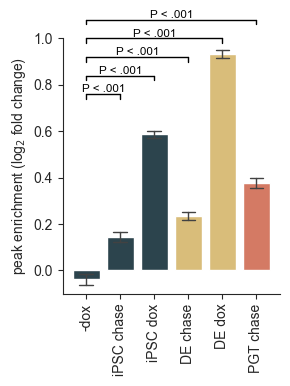

In [6]:
# Plot
plt.figure(figsize=(3, 4))
sns.barplot(data=fc_df, x="Sample", y="FC", hue="Sample", errorbar=("ci", 95), capsize=0.4, err_kws={"linewidth": 1},
            palette=[palette["iPSC"]]*3 + [palette["DE"]]*2 + [palette["PGT"]])
plt.xticks(rotation=90)
plt.ylim(-0.1, 1)
plt.ylabel("peak enrichment (log$_2$ fold change)")
plt.xlabel("")

# Statistics
for y1, y2, x1, x2, label in [[0.74, 0.76, 0, 1, "P < .001"], [0.82, 0.84, 0, 2, "P < .001"], [0.9, 0.92, 0, 3, "P < .001"],
                             [0.98, 1, 0, 4, "P < .001"], [1.06, 1.08, 0, 5, "P < .001"]]:
    plt.plot((x1, x1), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x2, x2), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x1, x2), (y2, y2), color="black", linewidth=1, clip_on=False)
    plt.text((x1+x2)/2, y2, label, ha="center", va="bottom", color="black", fontsize="small")

sns.despine()
plt.savefig(f"{output_dir}/SupplementalFigure8c.svg", format="svg")
plt.tight_layout()

## Figure 4a. DCM sites in and outside iPSC H3K27ac peaks

In [7]:
%%bash -s "{label}" "{output_dir}" "{input_dir}" 

mkdir -p "${2}/H3K27ac"

source /home/beatrice/miniconda3/etc/profile.d/conda.sh; conda activate map

bedtools slop -i "${3}/iPSC_H3K27ac.narrow.bed" -g "/mnt/data/BT/Ref/hg38/Sizes/sizes.genome" -b 5000 > "${2}/H3K27ac/iPSC_H3K27ac.slop.bed"
sed -i "s/^/chr/" "${2}/H3K27ac/iPSC_H3K27ac.slop.bed"
bedtools intersect -wo -a "${2}/H3K27ac/iPSC_H3K27ac.slop.bed" -b /mnt/data/BT/Ref/MeD-seq/Sites/HG38_DCM_index.bed \
              > "${2}/H3K27ac/iPSC_H3K27ac.slop.DCM.bed"

In [8]:
peaks_dcm = pd.read_csv(f"{output_dir}/H3K27ac/iPSC_H3K27ac.slop.DCM.bed", sep="\t", header=None, index_col=None)
peaks_dcm["Start"] = peaks_dcm[1] + 5000
peaks_dcm["End"] = peaks_dcm[2] - 5000
peaks_dcm["within"] = (peaks_dcm[11] < peaks_dcm["End"]) & (peaks_dcm[12] > peaks_dcm["Start"])
peaks_dcm["upstream"] = peaks_dcm[12] <= peaks_dcm["Start"]
peaks_dcm["downstream"] = peaks_dcm[11] >= peaks_dcm["End"]

summary_df = peaks_dcm.groupby(3)[["within", "upstream", "downstream"]].sum().reset_index()
summary_df = summary_df.rename(columns={"within": "nr_within", "upstream": "nr_upstream", "downstream": "nr_downstream", 3: "peak_id"})

def list_sites(df, mask_col):
    return df.loc[df[mask_col], 14].tolist() 
    
summary_df["DCMwithin"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["within"], 14].tolist(), include_groups=False).values
summary_df["DCMupstream"] = peaks_dcm.groupby(3).apply(lambda g: list_sites(g, "upstream"), include_groups=False).values
summary_df["DCMdownstream"] = peaks_dcm.groupby(3).apply(lambda g: list_sites(g, "downstream"), include_groups=False).values

display(summary_df)

,peak_id,nr_within,nr_upstream,nr_downstream,DCMwithin,DCMupstream,DCMdownstream
0,iPSC_H3K27ac_peak_1,10,32,25,"[136, 137, 138, 139, 140, 141, 142, 143, 144, ...","[104, 105, 106, 107, 108, 109, 110, 111, 112, ...","[146, 147, 148, 149, 150, 151, 152, 153, 154, ..."
1,iPSC_H3K27ac_peak_10,3,36,22,"[2904, 2905, 2906]","[2868, 2869, 2870, 2871, 2872, 2873, 2874, 287...","[2907, 2908, 2909, 2910, 2911, 2912, 2913, 291..."
2,iPSC_H3K27ac_peak_100,3,46,51,"[9727, 9728, 9729]","[9681, 9682, 9683, 9684, 9685, 9686, 9687, 968...","[9730, 9731, 9732, 9733, 9734, 9735, 9736, 973..."
3,iPSC_H3K27ac_peak_1000,14,13,24,"[106306, 106307, 106308, 106309, 106310, 10631...","[106293, 106294, 106295, 106296, 106297, 10629...","[106320, 106321, 106322, 106323, 106324, 10632..."
4,iPSC_H3K27ac_peak_10000,3,29,21,"[789687, 789688, 789689]","[789658, 789659, 789660, 789661, 789662, 78966...","[789690, 789691, 789692, 789693, 789694, 78969..."
...,...,...,...,...,...,...,...
120293,iPSC_H3K27ac_peak_99995,4,23,16,"[8485944, 8485945, 8485946, 8485947]","[8485921, 8485922, 8485923, 8485924, 8485925, ...","[8485948, 8485949, 8485950, 8485951, 8485952, ..."
120294,iPSC_H3K27ac_peak_99996,6,19,20,"[8486111, 8486112, 8486113, 8486114, 8486115, ...","[8486092, 8486093, 8486094, 8486095, 8486096, ...","[8486117, 8486118, 8486119, 8486120, 8486121, ..."
120295,iPSC_H3K27ac_peak_99997,14,14,15,"[8486117, 8486118, 8486119, 8486120, 8486121, ...","[8486103, 8486104, 8486105, 8486106, 8486107, ...","[8486131, 8486132, 8486133, 8486134, 8486135, ..."
120296,iPSC_H3K27ac_peak_99998,1,22,19,[8486131],"[8486109, 8486110, 8486111, 8486112, 8486113, ...","[8486132, 8486133, 8486134, 8486135, 8486136, ..."


In [9]:
peaks_dcm["Location"] = np.select([(peaks_dcm[11] < peaks_dcm["End"]) & (peaks_dcm[12] > peaks_dcm["Start"]),
                                       peaks_dcm[12] <= peaks_dcm["Start"], peaks_dcm[11] >= peaks_dcm["End"]],
                                      ["within", "upstream", "downstream"], default="other")

summary_df = (peaks_dcm.groupby(3)["Location"].value_counts().unstack(fill_value=0).reset_index().rename(columns={
        3: "peak_id", "within": "nr_within", "upstream": "nr_upstream", "downstream": "nr_downstream"}))

summary_df["Chr"] = peaks_dcm.groupby(3)[0].first().values
for region in ["within", "upstream", "downstream"]:
    summary_df[f"DCM_{region}"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["Location"] == region, 14].tolist(), include_groups=False).values
    summary_df[f"DCM_{region}_start"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["Location"] == region, 11].tolist(), include_groups=False).values
    summary_df[f"DCM_{region}_end"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["Location"] == region, 12].tolist(), include_groups=False).values
summary_df = summary_df[(summary_df["nr_upstream"] >= nr_adj_sites) & (summary_df["nr_downstream"] >= nr_adj_sites)]
display(summary_df)

Location,peak_id,nr_downstream,nr_upstream,nr_within,Chr,DCM_within,DCM_within_start,DCM_within_end,DCM_upstream,DCM_upstream_start,DCM_upstream_end,DCM_downstream,DCM_downstream_start,DCM_downstream_end
0,iPSC_H3K27ac_peak_1,25,32,10,chr1,"[136, 137, 138, 139, 140, 141, 142, 143, 144, ...","[28713, 28811, 28897, 29080, 29273, 29466, 295...","[28718, 28816, 28902, 29085, 29278, 29471, 295...","[104, 105, 106, 107, 108, 109, 110, 111, 112, ...","[23368, 23496, 23512, 23617, 23687, 23883, 240...","[23373, 23501, 23517, 23622, 23692, 23888, 240...","[146, 147, 148, 149, 150, 151, 152, 153, 154, ...","[31008, 31248, 31262, 31319, 31523, 31685, 318...","[31013, 31253, 31267, 31324, 31528, 31690, 318..."
1,iPSC_H3K27ac_peak_10,22,36,3,chr1,"[2904, 2905, 2906]","[845181, 845240, 845399]","[845186, 845245, 845404]","[2868, 2869, 2870, 2871, 2872, 2873, 2874, 287...","[840283, 840577, 840776, 841303, 841369, 84139...","[840288, 840582, 840781, 841308, 841374, 84140...","[2907, 2908, 2909, 2910, 2911, 2912, 2913, 291...","[845802, 845890, 845909, 846099, 846241, 84628...","[845807, 845895, 845914, 846104, 846246, 84628..."
2,iPSC_H3K27ac_peak_100,51,46,3,chr1,"[9727, 9728, 9729]","[1599729, 1599819, 1599907]","[1599734, 1599824, 1599912]","[9681, 9682, 9683, 9684, 9685, 9686, 9687, 968...","[1594718, 1594738, 1594822, 1596875, 1596924, ...","[1594723, 1594743, 1594827, 1596880, 1596929, ...","[9730, 9731, 9732, 9733, 9734, 9735, 9736, 973...","[1600549, 1600964, 1600977, 1600983, 1600995, ...","[1600554, 1600969, 1600982, 1600988, 1601000, ..."
3,iPSC_H3K27ac_peak_1000,24,13,14,chr1,"[106306, 106307, 106308, 106309, 106310, 10631...","[16656703, 16656724, 16656770, 16656794, 16656...","[16656708, 16656729, 16656775, 16656799, 16656...","[106293, 106294, 106295, 106296, 106297, 10629...","[16651969, 16652510, 16653507, 16653969, 16654...","[16651974, 16652515, 16653512, 16653974, 16654...","[106320, 106321, 106322, 106323, 106324, 10632...","[16657502, 16657638, 16657846, 16658039, 16658...","[16657507, 16657643, 16657851, 16658044, 16658..."
4,iPSC_H3K27ac_peak_10000,21,29,3,chr1,"[789687, 789688, 789689]","[230879459, 230879485, 230879501]","[230879464, 230879490, 230879506]","[789658, 789659, 789660, 789661, 789662, 78966...","[230874853, 230874872, 230874929, 230875017, 2...","[230874858, 230874877, 230874934, 230875022, 2...","[789690, 789691, 789692, 789693, 789694, 78969...","[230881606, 230881909, 230882074, 230882287, 2...","[230881611, 230881914, 230882079, 230882292, 2..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120293,iPSC_H3K27ac_peak_99995,16,23,4,chr7,"[8485944, 8485945, 8485946, 8485947]","[25895448, 25895570, 25895712, 25895791]","[25895453, 25895575, 25895717, 25895796]","[8485921, 8485922, 8485923, 8485924, 8485925, ...","[25890962, 25891392, 25891518, 25891854, 25892...","[25890967, 25891397, 25891523, 25891859, 25892...","[8485948, 8485949, 8485950, 8485951, 8485952, ...","[25896017, 25897151, 25897662, 25898319, 25898...","[25896022, 25897156, 25897667, 25898324, 25898..."
120294,iPSC_H3K27ac_peak_99996,20,19,6,chr7,"[8486111, 8486112, 8486113, 8486114, 8486115, ...","[25949594, 25949707, 25949860, 25949874, 25950...","[25949599, 25949712, 25949865, 25949879, 25950...","[8486092, 8486093, 8486094, 8486095, 8486096, ...","[25944827, 25944939, 25944976, 25945063, 25945...","[25944832, 25944944, 25944981, 25945068, 25945...","[8486117, 8486118, 8486119, 8486120, 8486121, ...","[25951455, 25951466, 25951510, 25951577, 25951...","[25951460, 25951471, 25951515, 25951582, 25951..."
120295,iPSC_H3K27ac_peak_99997,15,14,14,chr7,"[8486117, 8486118, 8486119, 8486120, 8486121, ...","[25951455, 25951466, 25951510, 25951577, 25951...","[25951460, 25951471, 25951515, 25951582, 25951...","[8486103, 8486104, 8486105, 8486106, 8486107, ...","[25946658, 25946725, 25947721, 25947774, 25948...","[25946663, 25946730, 25947726, 25947779, 25948...","[8486131, 8486132, 8486133, 8486134, 8486135, ...","[25953725, 25954536

In [10]:
with open(f"{output_dir}/H3K27ac/iPSC_H3K27ac.DCMsites.bed", "w") as out:
    for index, row in summary_df.iterrows():
        peak_id = row["peak_id"]
        chrom = row["Chr"]
        
        for region in ["upstream", "within", "downstream"]:
            list_sites = row[f"DCM_{region}"]
            list_start = row[f"DCM_{region}_start"]
            list_end = row[f"DCM_{region}_end"]

            if region == "upstream":
                list_sites, list_start, list_end = list_sites[-nr_adj_sites:], list_start[-nr_adj_sites:], list_end[-nr_adj_sites:]
            elif region == "downstream":
                list_sites, list_start, list_end = list_sites[:nr_adj_sites], list_start[:nr_adj_sites], list_end[:nr_adj_sites]
            else:
                list_sites, list_start, list_end = list_sites[:], list_start[:], list_end[:]
                
            for i, (site, start, end) in enumerate(zip(list_sites, list_start, list_end)):
                peak_bin = i if region == "upstream" else nr_adj_sites if region == "within" else nr_adj_sites + 1 + i
                out.write(f"{chrom}\t{start}\t{end}\t{peak_id}.{region}.{site}.{peak_bin}\n")         

In [11]:
%%bash -s "{label}" "{output_dir}" "{input_dir}" 

source /home/beatrice/miniconda3/etc/profile.d/conda.sh; conda activate map

bws="${3}/GEO/iPSC_nodox.bw ${3}/GEO/iPSC_dox.bw ${3}/GEO/iPSC_chase.bw ${3}/GEO/DE_chase.bw"

multiBigwigSummary BED-file --bwfiles ${bws} --BED ${2}/H3K27ac/iPSC_H3K27ac.DCMsites.bed -p 20 \
                   --outFileName ${2}/H3K27ac/iPSC_H3K27ac.DCMsites.npz --outRawCounts ${2}/H3K27ac/iPSC_H3K27ac.DCMsites.tsv

Number of bins found: 1606386


In [12]:
dcm_scores = pd.read_csv(f"{output_dir}/H3K27ac/iPSC_H3K27ac.DCMsites.tsv", sep="\t", dtype={0: str})
dcm_scores.columns = [column.strip("#").strip("'").strip(".bw").replace("_", " ").replace("no", "-") for column in dcm_scores.columns]
bed_df = pd.read_csv(f"{output_dir}/H3K27ac/iPSC_H3K27ac.DCMsites.bed", sep="\t", header=None, names=["Chr", "Start", "End", "ID"])
dcm_scores = pd.concat([dcm_scores, bed_df], axis=1)
dcm_scores[["peak", "region", "site", "bin"]] = dcm_scores["ID"].str.split(".", expand=True)
dcm_scores_mean = dcm_scores.groupby(["peak", "bin"])[["iPSC -dox", "iPSC dox", "iPSC chase", "DE chase"]].mean()
display(dcm_scores_mean)

dcm_scores_mean_wide = dcm_scores_mean.copy()
dcm_scores_mean_wide = dcm_scores_mean_wide.reset_index()
dcm_scores_mean_wide = dcm_scores_mean_wide.pivot(index="peak", columns="bin", values="iPSC dox")
dcm_scores_mean_wide.columns = dcm_scores_mean_wide.columns.astype(int)
dcm_scores_mean_wide = dcm_scores_mean_wide.sort_index(axis=1)
dcm_scores_mean_wide = (dcm_scores_mean_wide.sub(dcm_scores_mean_wide.mean(1), axis=0)).div(dcm_scores_mean_wide.std(1), axis=0)
dcm_scores_mean_wide = dcm_scores_mean_wide.melt(var_name="bin", value_name="DCM score")
display(dcm_scores_mean_wide)

iPSC -dox  iPSC dox  iPSC chase  DE chase
peak                    bin                                           
iPSC_H3K27ac_peak_1     0     0.000000  0.000000    0.000000  0.058211
                        1     0.000000  0.134795    0.000000  0.000000
                        10    0.028280  0.127281    0.699165  0.493906
                        2     0.039507  0.198979    0.271606  0.472885
                        3     0.000000  0.016995    0.000000  0.174632
...                                ...       ...         ...       ...
iPSC_H3K27ac_peak_99999 5     0.003404  0.026142    0.000000  0.000000
                        6     0.019754  0.171717    0.046546  0.062818
                        7     0.000000  0.070792    0.000000  0.000000
                        8     0.000000  0.000000    0.000000  0.000000
                        9     0.000000  0.000000    0.000000  0.000000

[1244296 rows x 4 columns]

,bin,DCM score
0,0,-0.813094
1,0,-0.884197
2,0,0.319542
3,0,0.216496
4,0,-0.736833
...,...,...
1265127,10,0.436374
1265128,10,0.001494
1265129,10,-0.865432
1265130,10,-0.530236


In [13]:
# Load and merge data
dcm_scores = pd.concat([pd.read_csv(f"{output_dir}/H3K27ac/iPSC_H3K27ac.DCMsites.tsv", sep="\t", dtype={0: str}),
                        pd.read_csv(f"{output_dir}/H3K27ac/iPSC_H3K27ac.DCMsites.bed", sep="\t", 
                                    header=None, names=["Chr", "Start", "End", "ID"])], axis=1)
dcm_scores.columns = [c.strip("#'.bw").replace("_", " ").replace("no", "-") for c in dcm_scores.columns]
dcm_scores[["peak", "region", "site", "bin"]] = dcm_scores["ID"].str.split(".", expand=True)
display(dcm_scores)

# Create df with bins as columns and peak regions as rows (column 5 is mean of all sites within peak)
dcm_scores_mean_wide = (dcm_scores.groupby(["peak", "bin"])[["iPSC -dox", "iPSC dox", "iPSC chase", "DE chase"]].mean()
                        .reset_index().pivot(index="peak", columns="bin", values="iPSC dox").rename(columns=int).sort_index(axis=1))
display(dcm_scores_mean_wide)

# Z-score per row
dcm_z_scores = sp.stats.zscore(dcm_scores_mean_wide, axis=1)
dcm_z_scores = dcm_z_scores.melt(var_name="bin", value_name="DCM score")
display(dcm_z_scores)

,chr,start,end,iPSC -dox,iPSC dox,iPSC chase,DE chase,Chr,Start,End,ID,peak,region,site,bin
0,6,219460,219465,0.000000,0.000000,0.000000,0.058211,chr1,27062,27067,iPSC_H3K27ac_peak_1.upstream.131.0,iPSC_H3K27ac_peak_1,upstream,131,0
1,6,219789,219794,0.000000,0.134795,0.000000,0.000000,chr1,27068,27073,iPSC_H3K27ac_peak_1.upstream.132.1,iPSC_H3K27ac_peak_1,upstream,132,1
2,6,219955,219960,0.039507,0.198979,0.271606,0.472885,chr1,27095,27100,iPSC_H3K27ac_peak_1.upstream.133.2,iPSC_H3K27ac_peak_1,upstream,133,2
3,6,220094,220099,0.000000,0.016995,0.000000,0.174632,chr1,27305,27310,iPSC_H3K27ac_peak_1.upstream.134.3,iPSC_H3K27ac_peak_1,upstream,134,3
4,6,220644,220649,0.000000,0.006027,0.000000,0.000000,chr1,28278,28283,iPSC_H3K27ac_peak_1.upstream.135.4,iPSC_H3K27ac_peak_1,upstream,135,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1606381,Y,24527425,24527430,0.019754,0.171717,0.046546,0.062818,chr7,25956036,25956041,iPSC_H3K27ac_peak_99999.downstream.8486136.6,iPSC_H3K27ac_peak_99999,downstream,8486136,6
1606382,Y,24527475,24527480,0.000000,0.070792,0.000000,0.000000,chr7,25957332,25957337,iPSC_H3K27ac_peak_99999.downstream.8486137.7,iPSC_H3K27ac_peak_99999,downstream,8486137,7
1606383,Y,24527775,24527780,0.000000,0.000000,0.000000,0.000000,chr7,25957382,25957387,iPSC_H3K27ac_peak_99999.downstream.8486138.8,iPSC_H3K27ac_peak_99999,downstream,8486138,8
1606384,Y,24527845,24527850,0.000000,0.000000,0.000000,0.000000,chr7,25957449,25957454,iPSC_H3K27ac_peak_99999.downstream.8486139.9,iPSC_H3K27ac_peak_99999,downstream,8486139,9


bin,0,1,2,3,4,5,6,7,8,9,10
peak,,,,,,,,,,,
iPSC_H3K27ac_peak_1,0.000000,0.134795,0.198979,0.016995,0.006027,0.084611,0.178145,0.103558,0.032322,0.581147,0.127281
iPSC_H3K27ac_peak_10,0.000000,0.000000,0.057011,0.132102,0.058618,0.151011,0.075091,0.340946,0.007694,0.012054,0.246227
iPSC_H3K27ac_peak_100,0.081118,0.009301,0.113621,0.000000,0.123323,0.027401,0.000000,0.006027,0.148636,0.133128,0.043290
iPSC_H3K27ac_peak_1000,0.085418,0.027441,0.119647,0.009301,0.152474,0.088816,0.067979,0.176418,0.061371,0.000000,0.009301
iPSC_H3K27ac_peak_10000,0.027902,0.023022,0.080657,0.080657,0.064124,0.072165,0.044436,0.000000,0.009301,0.112355,0.079511
...,...,...,...,...,...,...,...,...,...,...,...
iPSC_H3K27ac_peak_99995,0.000000,0.000000,0.000000,0.000000,0.000000,0.076728,0.072800,0.072800,0.009301,0.009301,0.040076
iPSC_H3K27ac_peak_99996,0.040076,0.023082,0.015388,0.084973,0.016995,0.048853,0.087726,0.006027,0.015388,0.016995,0.035596
iPSC_H3K27ac_peak_99997,0.000000,0.000000,0.007694,0.007694,0.007694,0.008546,0.000000,0.000000,0.009301,0.000000,0.000000


,bin,DCM score
0,0,-0.852780
1,0,-0.927354
2,0,0.335138
3,0,0.227063
4,0,-0.772797
...,...,...
1265127,10,0.457673
1265128,10,0.001567
1265129,10,-0.907672
1265130,10,-0.556117


In [14]:
# Statistics
results = {}
for site in [4, 6]:
    stat, p = sp.stats.wilcoxon(dcm_scores_mean_wide[site], dcm_scores_mean_wide[5], alternative="two-sided", nan_policy="omit")
    results[site] = {"stat": stat, "pval": p}

results_df = pd.DataFrame(results).T
results_df["padj"] = multipletests(results_df["pval"], method="bonferroni")[1]
print(results_df)

           stat           pval           padj
4  1.663818e+09  2.049214e-110  4.098428e-110
6  1.680613e+09   2.028675e-99   4.057350e-99


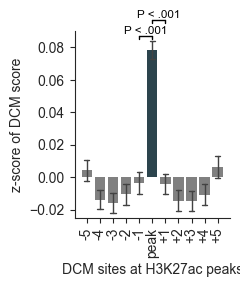

In [15]:
plt.figure(figsize=(2.5, 3))

sns.barplot(data=dcm_z_scores, x="bin", y="DCM score", hue="bin", linewidth=0,
            errorbar=("ci", 95), capsize=0.4, err_kws={"linewidth": 1}, palette=["gray"]*nr_adj_sites + [palette["iPSC"]] + ["gray"]*nr_adj_sites)
plt.ylim(-0.025, 0.09)
plt.xticks(range(0,11), [-5, -4, -3, -2, -1, "peak", "+1", "+2", "+3", "+4", "+5"], rotation=90)
plt.ylabel("z-score of DCM score")
plt.xlabel("DCM sites at H3K27ac peaks")
plt.legend().set_visible(False)

# Statistics
for y1, y2, x1, x2, label in [[0.085, 0.087, nr_adj_sites-1, nr_adj_sites, "P < .001"], [0.095, 0.097, nr_adj_sites, nr_adj_sites+1, "P < .001"]]:
    plt.plot((x1, x1), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x2, x2), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x1, x2), (y2, y2), color="black", linewidth=1, clip_on=False)
    plt.text((x1+x2)/2, y2, label, ha="center", va="bottom", color="black", fontsize="small")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/Figure4a.svg", format="svg")
plt.show()

## Figure S8d. DCM sites in and outside DE H3K27ac peaks

In [16]:
label = "SupplementalFigure7d"

In [17]:
%%bash -s "{label}" "{output_dir}" "{input_dir}" 

source /home/beatrice/miniconda3/etc/profile.d/conda.sh; conda activate map

bedtools slop -i "${3}/DE_H3K27ac.narrow.bed" -g "/mnt/data/BT/Ref/hg38/Sizes/sizes.genome" -b 5000 > "${2}/H3K27ac/DE_H3K27ac.slop.bed"
sed -i "s/^/chr/" "${2}/H3K27ac/DE_H3K27ac.slop.bed"
bedtools intersect -wo -a "${2}/H3K27ac/DE_H3K27ac.slop.bed" -b /mnt/data/BT/Ref/MeD-seq/Sites/HG38_DCM_index.bed \
              > "${2}/H3K27ac/DE_H3K27ac.slop.DCM.bed"

In [18]:
peaks_dcm = pd.read_csv(f"{output_dir}/H3K27ac/DE_H3K27ac.slop.DCM.bed", sep="\t", header=None, index_col=None)
peaks_dcm["Start"] = peaks_dcm[1] + 5000
peaks_dcm["End"] = peaks_dcm[2] - 5000
peaks_dcm["within"] = (peaks_dcm[11] < peaks_dcm["End"]) & (peaks_dcm[12] > peaks_dcm["Start"])
peaks_dcm["upstream"] = peaks_dcm[12] <= peaks_dcm["Start"]
peaks_dcm["downstream"] = peaks_dcm[11] >= peaks_dcm["End"]

summary_df = peaks_dcm.groupby(3)[["within", "upstream", "downstream"]].sum().reset_index()
summary_df = summary_df.rename(columns={"within": "nr_within", "upstream": "nr_upstream", "downstream": "nr_downstream", 3: "peak_id"})

def list_sites(df, mask_col):
    return df.loc[df[mask_col], 14].tolist() 
    
summary_df["DCMwithin"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["within"], 14].tolist(), include_groups=False).values
summary_df["DCMupstream"] = peaks_dcm.groupby(3).apply(lambda g: list_sites(g, "upstream"), include_groups=False).values
summary_df["DCMdownstream"] = peaks_dcm.groupby(3).apply(lambda g: list_sites(g, "downstream"), include_groups=False).values
display(summary_df)

,peak_id,nr_within,nr_upstream,nr_downstream,DCMwithin,DCMupstream,DCMdownstream
0,DE_H3K27ac_peak_1,7,28,26,"[137, 138, 139, 140, 141, 142, 143]","[109, 110, 111, 112, 113, 114, 115, 116, 117, ...","[144, 145, 146, 147, 148, 149, 150, 151, 152, ..."
1,DE_H3K27ac_peak_10,8,65,56,"[3532, 3533, 3534, 3535, 3536, 3537, 3538, 3539]","[3467, 3468, 3469, 3470, 3471, 3472, 3473, 347...","[3540, 3541, 3542, 3543, 3544, 3545, 3546, 354..."
2,DE_H3K27ac_peak_100,2,48,63,"[30872, 30873]","[30824, 30825, 30826, 30827, 30828, 30829, 308...","[30874, 30875, 30876, 30877, 30878, 30879, 308..."
3,DE_H3K27ac_peak_1000,1,20,30,[204904],"[204884, 204885, 204886, 204887, 204888, 20488...","[204905, 204906, 204907, 204908, 204909, 20491..."
4,DE_H3K27ac_peak_10000,5,23,30,"[1847121, 1847122, 1847123, 1847124, 1847125]","[1847098, 1847099, 1847100, 1847101, 1847102, ...","[1847126, 1847127, 1847128, 1847129, 1847130, ..."
...,...,...,...,...,...,...,...
52495,DE_H3K27ac_peak_9995,2,26,24,"[1846495, 1846496]","[1846469, 1846470, 1846471, 1846472, 1846473, ...","[1846497, 1846498, 1846499, 1846500, 1846501, ..."
52496,DE_H3K27ac_peak_9996,28,19,33,"[1846689, 1846690, 1846691, 1846692, 1846693, ...","[1846670, 1846671, 1846672, 1846673, 1846674, ...","[1846717, 1846718, 1846719, 1846720, 1846721, ..."
52497,DE_H3K27ac_peak_9997,6,33,32,"[1846847, 1846848, 1846849, 1846850, 1846851, ...","[1846814, 1846815, 1846816, 1846817, 1846818, ...","[1846853, 1846854, 1846855, 1846856, 1846857, ..."
52498,DE_H3K27ac_peak_9998,4,25,27,"[1846924, 1846925, 1846926, 1846927]","[1846899, 1846900, 1846901, 1846902, 1846903, ...","[1846928, 1846929, 1846930, 1846931, 1846932, ..."


In [19]:
peaks_dcm["Location"] = np.select([(peaks_dcm[11] < peaks_dcm["End"]) & (peaks_dcm[12] > peaks_dcm["Start"]),
                                       peaks_dcm[12] <= peaks_dcm["Start"], peaks_dcm[11] >= peaks_dcm["End"]],
                                      ["within", "upstream", "downstream"], default="other")

summary_df = (peaks_dcm.groupby(3)["Location"].value_counts().unstack(fill_value=0).reset_index().rename(columns={
        3: "peak_id", "within": "nr_within", "upstream": "nr_upstream", "downstream": "nr_downstream"}))

summary_df["Chr"] = peaks_dcm.groupby(3)[0].first().values
for region in ["within", "upstream", "downstream"]:
    summary_df[f"DCM_{region}"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["Location"] == region, 14].tolist(), include_groups=False).values
    summary_df[f"DCM_{region}_start"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["Location"] == region, 11].tolist(), include_groups=False).values
    summary_df[f"DCM_{region}_end"] = peaks_dcm.groupby(3).apply(lambda g: g.loc[g["Location"] == region, 12].tolist(), include_groups=False).values
summary_df = summary_df[(summary_df["nr_upstream"] >= nr_adj_sites) & (summary_df["nr_downstream"] >= nr_adj_sites)]
display(summary_df)

Location,peak_id,nr_downstream,nr_upstream,nr_within,Chr,DCM_within,DCM_within_start,DCM_within_end,DCM_upstream,DCM_upstream_start,DCM_upstream_end,DCM_downstream,DCM_downstream_start,DCM_downstream_end
0,DE_H3K27ac_peak_1,26,28,7,chr1,"[137, 138, 139, 140, 141, 142, 143]","[28811, 28897, 29080, 29273, 29466, 29515, 29759]","[28816, 28902, 29085, 29278, 29471, 29520, 29764]","[109, 110, 111, 112, 113, 114, 115, 116, 117, ...","[23883, 24001, 24098, 24116, 24344, 24517, 245...","[23888, 24006, 24103, 24121, 24349, 24522, 245...","[144, 145, 146, 147, 148, 149, 150, 151, 152, ...","[29992, 30296, 31008, 31248, 31262, 31319, 315...","[29997, 30301, 31013, 31253, 31267, 31324, 315..."
1,DE_H3K27ac_peak_10,56,65,8,chr1,"[3532, 3533, 3534, 3535, 3536, 3537, 3538, 3539]","[942189, 942216, 942247, 942273, 942405, 94244...","[942194, 942221, 942252, 942278, 942410, 94245...","[3467, 3468, 3469, 3470, 3471, 3472, 3473, 347...","[937092, 937165, 937202, 937260, 937267, 93742...","[937097, 937170, 937207, 937265, 937272, 93742...","[3540, 3541, 3542, 3543, 3544, 3545, 3546, 354...","[942729, 943000, 943017, 943396, 943435, 94354...","[942734, 943005, 943022, 943401, 943440, 94355..."
2,DE_H3K27ac_peak_100,63,48,2,chr1,"[30872, 30873]","[3772334, 3772412]","[3772339, 3772417]","[30824, 30825, 30826, 30827, 30828, 30829, 308...","[3767131, 3767423, 3767440, 3767499, 3767757, ...","[3767136, 3767428, 3767445, 3767504, 3767762, ...","[30874, 30875, 30876, 30877, 30878, 30879, 308...","[3772504, 3772600, 3772746, 3772894, 3772933, ...","[3772509, 3772605, 3772751, 3772899, 3772938, ..."
3,DE_H3K27ac_peak_1000,30,20,1,chr1,[204904],[32964705],[32964710],"[204884, 204885, 204886, 204887, 204888, 20488...","[32959584, 32959905, 32960022, 32960607, 32960...","[32959589, 32959910, 32960027, 32960612, 32960...","[204905, 204906, 204907, 204908, 204909, 20491...","[32964996, 32965047, 32965445, 32965499, 32965...","[32965001, 32965052, 32965450, 32965504, 32965..."
4,DE_H3K27ac_peak_10000,30,23,5,chr12,"[1847121, 1847122, 1847123, 1847124, 1847125]","[6606272, 6606357, 6606389, 6606760, 6607155]","[6606277, 6606362, 6606394, 6606765, 6607160]","[1847098, 1847099, 1847100, 1847101, 1847102, ...","[6601738, 6601951, 6602059, 6602649, 6602700, ...","[6601743, 6601956, 6602064, 6602654, 6602705, ...","[1847126, 1847127, 1847128, 1847129, 1847130, ...","[6607528, 6607612, 6607631, 6608174, 6608496, ...","[6607533, 6607617, 6607636, 6608179, 6608501, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52495,DE_H3K27ac_peak_9995,24,26,2,chr12,"[1846495, 1846496]","[6494150, 6494254]","[6494155, 6494259]","[1846469, 1846470, 1846471, 1846472, 1846473, ...","[6489163, 6489216, 6489234, 6489302, 6489364, ...","[6489168, 6489221, 6489239, 6489307, 6489369, ...","[1846497, 1846498, 1846499, 1846500, 1846501, ...","[6494852, 6495313, 6495514, 6495825, 6495833, ...","[6494857, 6495318, 6495519, 6495830, 6495838, ..."
52496,DE_H3K27ac_peak_9996,33,19,28,chr12,"[1846689, 1846690, 1846691, 1846692, 1846693, ...","[6532767, 6532907, 6533073, 6533164, 6533347, ...","[6532772, 6532912, 6533078, 6533169, 6533352, ...","[1846670, 1846671, 1846672, 1846673, 1846674, ...","[6528020, 6528303, 6528360, 6528401, 6528468, ...","[6528025, 6528308, 6528365, 6528406, 6528473, ...","[1846717, 1846718, 1846719, 1846720, 1846721, ...","[6536167, 6536253, 6536291, 6536323, 6536332, ...","[6536172, 6536258, 6536296, 6536328, 6536337, ..."
52497,DE_H3K27ac_peak_9997,32,33,6,chr12,"[1846847, 1846848, 1846849, 1846850, 1846851, ...","[6555617, 6555656, 6555671, 6555764, 6555818, ...","[6555622, 6555661, 6555676, 6555769, 6555823, ...","[1846814, 1846815, 1846816, 1846817, 1846818, ...","[6550677, 6550762, 6550780, 6550901, 6550942, ...","[6550682, 6550767, 6550785, 6550906, 6550947, ...","[1846853, 1846854, 1846855, 1846856, 1846857, ...","[6556208, 6556259, 6556288, 6556428, 6556545, ...","[6556213, 6556264, 6556293, 6556433, 6556550, ..."
52498,DE_H3K27ac_peak_9998,27,25,4

In [20]:
with open(f"{output_dir}/H3K27ac/DE_H3K27ac.DCMsites.bed", "w") as out:
    for index, row in summary_df.iterrows():
        peak_id = row["peak_id"]
        chrom = row["Chr"]
        
        for region in ["upstream", "within", "downstream"]:
            list_sites = row[f"DCM_{region}"]
            list_start = row[f"DCM_{region}_start"]
            list_end = row[f"DCM_{region}_end"]

            if region == "upstream":
                list_sites, list_start, list_end = list_sites[-nr_adj_sites:], list_start[-nr_adj_sites:], list_end[-nr_adj_sites:]
            elif region == "downstream":
                list_sites, list_start, list_end = list_sites[:nr_adj_sites], list_start[:nr_adj_sites], list_end[:nr_adj_sites]
            else:
                list_sites, list_start, list_end = list_sites[:], list_start[:], list_end[:]
                
            for i, (site, start, end) in enumerate(zip(list_sites, list_start, list_end)):
                peak_bin = i if region == "upstream" else nr_adj_sites if region == "within" else nr_adj_sites + 1 + i
                out.write(f"{chrom}\t{start}\t{end}\t{peak_id}.{region}.{site}.{peak_bin}\n")         

In [21]:
%%bash -s "{label}" "{output_dir}" "{input_dir}" 

source /home/beatrice/miniconda3/etc/profile.d/conda.sh; conda activate map

bws="${3}/GEO/DE_dox.bw ${3}/GEO/PGT_chase.bw"

multiBigwigSummary BED-file --bwfiles ${bws} --BED ${2}/H3K27ac/DE_H3K27ac.DCMsites.bed -p 20 \
                   --outFileName ${2}/H3K27ac/DE_H3K27ac.DCMsites.npz --outRawCounts ${2}/H3K27ac/DE_H3K27ac.DCMsites.tsv

Number of bins found: 657610


In [22]:
dcm_scores = pd.read_csv(f"{output_dir}/H3K27ac/DE_H3K27ac.DCMsites.tsv", sep="\t", dtype={0: str})
dcm_scores.columns = [column.strip("#").strip("'").strip(".bw").replace("_", " ").replace("no", "-") for column in dcm_scores.columns]
bed_df = pd.read_csv(f"{output_dir}/H3K27ac/DE_H3K27ac.DCMsites.bed", sep="\t", header=None, names=["Chr", "Start", "End", "ID"])
dcm_scores = pd.concat([dcm_scores, bed_df], axis=1)
dcm_scores[["peak", "region", "site", "bin"]] = dcm_scores["ID"].str.split(".", expand=True)
dcm_scores_mean = dcm_scores.groupby(["peak", "bin"])[["DE dox", "PGT chase"]].mean()
display(dcm_scores_mean)

dcm_scores_mean_wide = dcm_scores_mean.copy()
dcm_scores_mean_wide = dcm_scores_mean_wide.reset_index()
dcm_scores_mean_wide = dcm_scores_mean_wide.pivot(index="peak", columns="bin", values="DE dox")
dcm_scores_mean_wide.columns = dcm_scores_mean_wide.columns.astype(int)
dcm_scores_mean_wide = dcm_scores_mean_wide.sort_index(axis=1)
dcm_scores_mean_wide = (dcm_scores_mean_wide.sub(dcm_scores_mean_wide.mean(1), axis=0)).div(dcm_scores_mean_wide.std(1), axis=0)
dcm_scores_mean_wide = dcm_scores_mean_wide.melt(var_name="bin", value_name="DCM score")
display(dcm_scores_mean_wide)

DE dox  PGT chase
peak                 bin                     
DE_H3K27ac_peak_1    0    0.174139   0.034451
                     1    0.083560   0.223581
                     10   0.012467   0.034451
                     2    0.072265   0.136260
                     3    0.012467   0.000000
...                            ...        ...
DE_H3K27ac_peak_9999 5    0.056747   0.010019
                     6    0.000000   0.000000
                     7    0.025323   0.000000
                     8    0.012467   0.030057
                     9    0.023568   0.030057

[545842 rows x 2 columns]

,bin,DCM score
0,0,1.769941
1,0,-0.786004
2,0,2.768202
3,0,-1.368337
4,0,1.427477
...,...,...
556617,10,0.030399
556618,10,-1.283473
556619,10,0.200708
556620,10,-0.506157


In [23]:
# Load and merge data
dcm_scores = pd.concat([pd.read_csv(f"{output_dir}/H3K27ac/DE_H3K27ac.DCMsites.tsv", sep="\t", dtype={0: str}),
                        pd.read_csv(f"{output_dir}/H3K27ac/DE_H3K27ac.DCMsites.bed", sep="\t", header=None, 
                                    names=["Chr", "Start", "End", "ID"])], axis=1)
dcm_scores.columns = [c.strip("#'.bw").replace("_", " ").replace("no", "-") for c in dcm_scores.columns]
dcm_scores[["peak", "region", "site", "bin"]] = dcm_scores["ID"].str.split(".", expand=True)
display(dcm_scores)

# Create df with bins as columns and peak regions as rows (column 5 is mean of all sites within peak)
dcm_scores_mean_wide = (dcm_scores.groupby(["peak", "bin"])[["DE dox", "PGT chase"]].mean()
                        .reset_index().pivot(index="peak", columns="bin", values="DE dox").rename(columns=int).sort_index(axis=1))
display(dcm_scores_mean_wide)

# Z-score per row
dcm_z_scores = sp.stats.zscore(dcm_scores_mean_wide, axis=1)
dcm_z_scores = dcm_z_scores.melt(var_name="bin", value_name="DCM score")
display(dcm_z_scores)

,chr,start,end,DE dox,PGT chase,Chr,Start,End,ID,peak,region,site,bin
0,5,52890,52895,0.174139,0.034451,chr1,27068,27073,DE_H3K27ac_peak_1.upstream.132.0,DE_H3K27ac_peak_1,upstream,132,0
1,5,52965,52970,0.083560,0.223581,chr1,27095,27100,DE_H3K27ac_peak_1.upstream.133.1,DE_H3K27ac_peak_1,upstream,133,1
2,5,53000,53005,0.072265,0.136260,chr1,27305,27310,DE_H3K27ac_peak_1.upstream.134.2,DE_H3K27ac_peak_1,upstream,134,2
3,5,53152,53157,0.012467,0.000000,chr1,28278,28283,DE_H3K27ac_peak_1.upstream.135.3,DE_H3K27ac_peak_1,upstream,135,3
4,5,53496,53501,0.119984,0.093022,chr1,28713,28718,DE_H3K27ac_peak_1.upstream.136.4,DE_H3K27ac_peak_1,upstream,136,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
657605,4,189950311,189950316,0.000000,0.000000,chr12,6569191,6569196,DE_H3K27ac_peak_9999.downstream.1846932.6,DE_H3K27ac_peak_9999,downstream,1846932,6
657606,4,189950736,189950741,0.025323,0.000000,chr12,6569336,6569341,DE_H3K27ac_peak_9999.downstream.1846933.7,DE_H3K27ac_peak_9999,downstream,1846933,7
657607,4,189951209,189951214,0.012467,0.030057,chr12,6569355,6569360,DE_H3K27ac_peak_9999.downstream.1846934.8,DE_H3K27ac_peak_9999,downstream,1846934,8
657608,4,189951293,189951298,0.023568,0.030057,chr12,6569573,6569578,DE_H3K27ac_peak_9999.downstream.1846935.9,DE_H3K27ac_peak_9999,downstream,1846935,9


bin,0,1,2,3,4,5,6,7,8,9,10
peak,,,,,,,,,,,
DE_H3K27ac_peak_1,0.174139,0.083560,0.072265,0.012467,0.119984,0.067758,0.072265,0.143358,0.000000,0.000000,0.012467
DE_H3K27ac_peak_10,0.012467,0.023762,0.023762,0.011101,0.011101,0.145992,0.061164,0.061164,0.033302,0.033302,0.059798
DE_H3K27ac_peak_100,0.649983,0.000000,0.023568,0.012467,0.147458,0.235788,0.087854,0.099149,0.000000,0.000000,0.000000
DE_H3K27ac_peak_1000,0.048503,0.131279,0.106740,0.211524,0.197302,0.216399,0.120178,0.143746,0.201789,0.082194,0.361318
DE_H3K27ac_peak_10000,0.295498,0.000000,0.058431,0.231406,0.346514,0.124699,0.072071,0.082000,0.082000,0.144725,0.144725
...,...,...,...,...,...,...,...,...,...,...,...
DE_H3K27ac_peak_9995,0.058431,0.012661,0.012661,0.012661,0.012661,0.118229,0.118229,0.118229,0.059798,0.059798,0.059798
DE_H3K27ac_peak_9996,0.059798,0.058431,0.058431,0.058431,0.058431,0.063866,0.155631,0.226530,0.132063,0.167120,0.012467
DE_H3K27ac_peak_9997,0.012467,0.012467,0.000000,0.000000,0.000000,0.020453,0.000000,0.023762,0.023762,0.012661,0.012661


,bin,DCM score
0,0,1.856329
1,0,-0.824368
2,0,2.903314
3,0,-1.435124
4,0,1.497151
...,...,...
556617,10,0.031882
556618,10,-1.346118
556619,10,0.210505
556620,10,-0.530861


In [24]:
# Statistics
results = {}
for site in [4, 6]:
    stat, p = sp.stats.wilcoxon(dcm_scores_mean_wide[site], dcm_scores_mean_wide[5], alternative="two-sided", nan_policy="omit")
    results[site] = {"stat": stat, "pval": p}

results_df = pd.DataFrame(results).T
results_df["padj"] = multipletests(results_df["pval"], method="bonferroni")[1]
print(results_df)

          stat          pval          padj
4  292265651.5  2.722507e-22  5.445015e-22
6  294171933.0  7.527151e-20  1.505430e-19


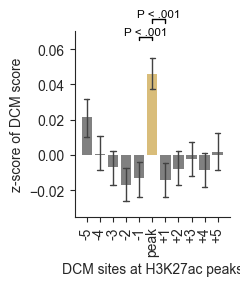

In [25]:
plt.figure(figsize=(2.5, 3))

sns.barplot(data=dcm_z_scores, x="bin", y="DCM score", hue="bin", linewidth=0,
            errorbar=("ci", 95), capsize=0.4, err_kws={"linewidth": 1}, palette=["gray"]*nr_adj_sites + [palette["DE"]] + ["gray"]*nr_adj_sites)
plt.ylim(-0.035, 0.07)
plt.xticks(range(0,11), [-5, -4, -3, -2, -1, "peak", "+1", "+2", "+3", "+4", "+5"], rotation=90)
plt.ylabel("z-score of DCM score")
plt.xlabel("DCM sites at H3K27ac peaks")
plt.legend().set_visible(False)

# Statistics
for y1, y2, x1, x2, label in [[0.065, 0.067, nr_adj_sites-1, nr_adj_sites, "P < .001"], [0.075, 0.077, nr_adj_sites, nr_adj_sites+1, "P < .001"]]:
    plt.plot((x1, x1), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x2, x2), (y1, y2), color="black", linewidth=1, clip_on=False)
    plt.plot((x1, x2), (y2, y2), color="black", linewidth=1, clip_on=False)
    plt.text((x1+x2)/2, y2, label, ha="center", va="bottom", color="black", fontsize="small")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure8d.svg", format="svg")
plt.show()